In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [94]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

## Search between 100Mb ref and 1Mb query

containing 10k matches of 50bp with 3 errors

In [104]:
ref_size="100Mb"
df = pd.read_csv(ref_size + "/search_efficiency_0.06.log", sep = "\t")
df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
more = df['more'].str.split('--',expand=True)

df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors
0,3.96,1487004,0.5,3
1,131.32,287716,0.5,3
2,5.40,2441628,0.5,3
3,61.97,379976,0.5,3
4,64.55,366892,0.5,3


In [105]:
to_remove = []
for col in more.columns:
    if (len(np.unique(more[col])) == 1):
        to_remove.append(col)

to_remove.append(14)
more.drop(to_remove, axis = 1, inplace = True)
more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "threads", "output-path"]
more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads"]:
    more[col] = more[col].str.removeprefix(col)

col = "output-path"
more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

col = "er"
more[col] = more[col].str.removeprefix("efficiency_")

more.head()

,exec-path,seg-count,cart-max-capacity,max-queued-carts,threads,ref-size,er
0,build,100,500,1024,32,100Mb,0.06
1,build_io,100,500,1024,1,100Mb,0.06
2,build_io,100,500,1024,32,100Mb,0.06
3,build_io,100,500,1024,2,100Mb,0.06
4,build_io,100,500,1024,2,100Mb,0.06


In [107]:
df = df.merge(more, how = "outer", left_index = True, right_index = True)
df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32'})
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,threads,ref-size,er
0,3.96,1487004,0.5,3,build,100,500,1024,32,100Mb,0.06
1,131.32,287716,0.5,3,build_io,100,500,1024,1,100Mb,0.06
2,5.40,2441628,0.5,3,build_io,100,500,1024,32,100Mb,0.06
3,61.97,379976,0.5,3,build_io,100,500,1024,2,100Mb,0.06
4,64.55,366892,0.5,3,build_io,100,500,1024,2,100Mb,0.06


In [108]:
bits_in_bt = "1377675"
ibf_size = 169 * 1024 * 1024

kmer_size = 18
shape_weight = 12
window_size = 20

bins = 1024
carts = 1024
database_size = 104857600
query_size = 1048610
min_len = 50

In [109]:
df = df[df["seg-count"]>100]
#df = df[df["cart-max-capacity"] > 1]
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,threads,ref-size,er
11,61.53,314900,0.5,3,build_io,3495,500,1024,2,100Mb,0.06
12,30.45,425932,0.5,3,build_io,3495,500,1024,4,100Mb,0.06
13,11.30,473280,0.5,3,build,3495,500,1024,2,100Mb,0.06
14,6.23,484580,0.5,3,build,3495,500,1024,4,100Mb,0.06
15,448.71,937072,0.5,3,build,3495,1,1024,1,100Mb,0.06


In [110]:
1048610 / 3495

300.0314735336195

In [111]:
build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "ref-size", "er"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "ref-size", "er"], axis = 1, inplace = True)

In [112]:
data = build.copy()
#data = data[data["cart-max-capacity"] > 1]
data["memory-model"] = (data["Memory (kb)"] * 1024 - (ibf_size + 2 * database_size + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 8
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1024), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1024)) * 100, 2)
data

kmers_per_segment	331


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
13,11.30,473280,500,1024,2,94017566,2648000,0.01,19.40
14,6.23,484580,500,1024,4,102940766,5296000,0.01,20.75
15,448.71,937072,1,1024,1,571585926,2648,0.00,59.57
16,71.32,478236,10,1024,1,101714030,26480,0.00,20.77
17,25.19,469852,100,1024,1,92890494,264800,0.00,19.31
18,21.13,470700,1000,1024,1,91375646,2648000,0.01,18.96
19,231.00,871572,1,1024,2,504511278,5296,0.00,56.53
20,36.51,481124,10,1024,2,104644862,52960,0.00,21.24
21,13.21,456276,100,1024,2,78723870,529600,0.00,16.85
22,11.05,475288,1000,1024,2,93425758,5296000,0.01,19.20


In [113]:
data = io.copy()
data = data[data["cart-max-capacity"] > 1]
ref_seg_count = 10
data["memory-model"] = (data["Memory (kb)"] * 1024 - (ibf_size + data["threads"] * 2 * database_size / ref_seg_count + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1024), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1024)) * 100, 2)
data

kmers_per_segment	331


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
11,61.53,314900,500,1024,2,101925606,331000,0.0,31.61
12,30.45,425932,500,1024,4,173348334,662000,0.0,39.74
28,1481.19,303344,10,1024,1,111391472,3310,0.0,35.86
29,247.04,274844,100,1024,1,82177682,33100,0.0,29.20
30,131.97,259940,1000,1024,1,66618086,331000,0.0,25.03
32,733.73,324892,10,1024,2,112481794,6620,0.0,33.81
33,109.83,306508,100,1024,2,93596998,66200,0.0,29.82
34,69.31,311864,1000,1024,2,98485742,662000,0.0,30.84
36,397.49,476964,10,1024,4,226253862,13240,0.0,46.32
37,56.23,410792,100,1024,4,158374574,132400,0.0,37.65


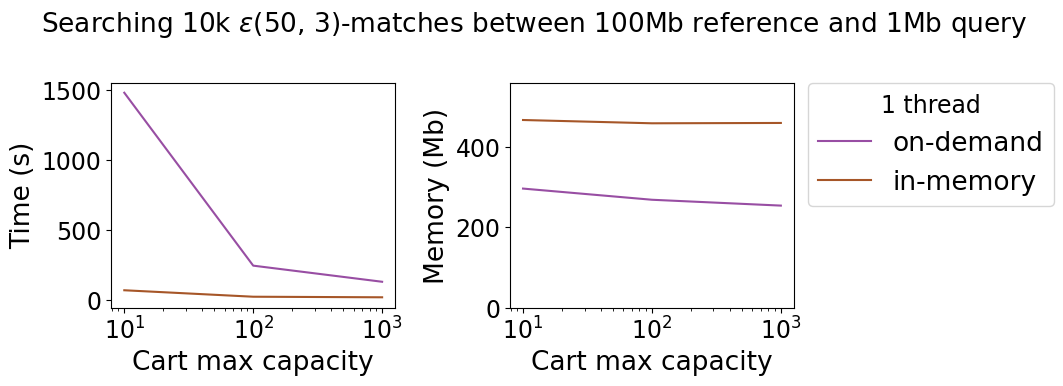

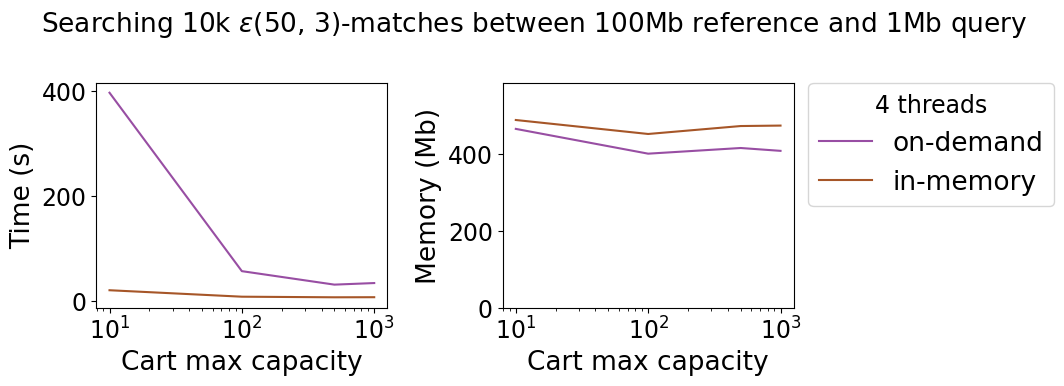

In [116]:
colors = [CB_color_cycle[5], CB_color_cycle[4]]
for t in [1, 4]:
    fig, ax = plt.subplots(1, 2)
    fig.set_size_inches(11, 4)

    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1024]
        data = data.sort_values('cart-max-capacity', ascending=True)
        ax[0].semilogx(data["cart-max-capacity"], data["Time (s)"], color = colors[i])
        i += 1
        
    labels = ["on-demand", "in-memory"]
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1024]
        data = data.sort_values('cart-max-capacity', ascending=True)
        ax[1].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
        ax[1].semilogx(data["cart-max-capacity"], data["Memory (kb)"] / 1024, label = labels[i], color = colors[i])
        i+=1
    
    #ax[0].set_title("It takes longer to process many small carts \n"
    #            "compared to few large carts")
    ax[0].set_ylabel("Time (s)")
    ax[0].set_xlabel("Cart max capacity")

    #ax[1].set_title("More memory for many small carts \n"
    #            "compared to few large carts")
    ax[1].set_ylabel("Memory (Mb)")
    ax[1].set_xlabel("Cart max capacity")

    if (t == 1):
        ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title = str(t) + " thread")
    else:
        ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title = str(t) + " threads")
    fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_cart_max_capacity_t" + str(t) + ".png", dpi=400, bbox_inches='tight')
    plt.show()

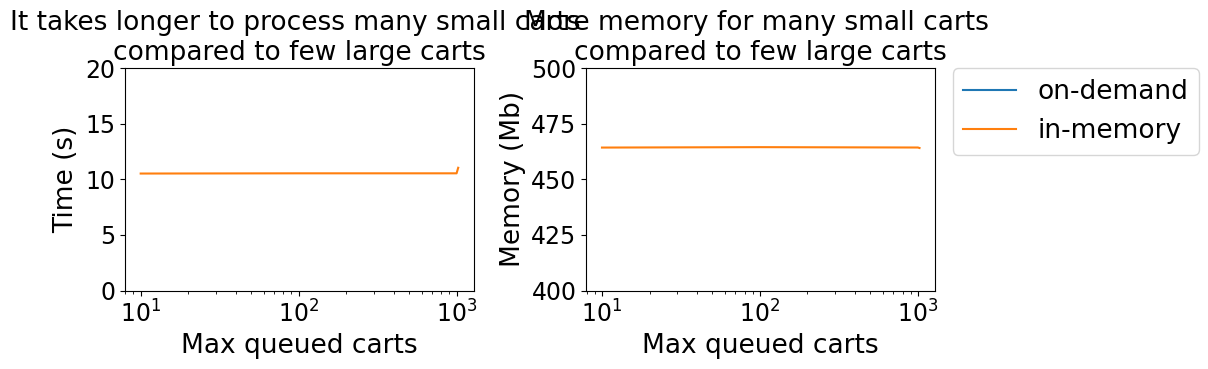

In [92]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(12, 4)

col = "max-queued-carts"
for t in [2]:
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] == 1000]
        data = data.sort_values(col, ascending=True)
        ax[0].semilogx(data[col], data["Time (s)"], color = colors[i])
        i += 1
        
    labels = ["on-demand", "in-memory"]
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] == 1000]
        data = data.sort_values(col, ascending=True)
        ax[1].semilogx(data[col], data["Memory (kb)"] / 1024, label = labels[i], color = colors[i])
        i+=1

    ax[0].set_title("It takes longer to process many small carts \n"
                "compared to few large carts")
    ax[0].set_ylabel("Time (s)")
    ax[0].set_xlabel("Max queued carts")
    ax[0].set_ylim(0, 20)
    ax[1].set_title("More memory for many small carts \n"
                "compared to few large carts")
    ax[1].set_ylabel("Memory (Mb)")
    ax[1].set_xlabel("Max queued carts")
    ax[1].set_ylim(400, 500)

    ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #fig.suptitle("Searching 10k matches between 100Mb ref and 1Mb query using " + str(t) + " threads")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_max_queued_carts_t" + str(t) + ".pdf", dpi=400, bbox_inches='tight')
    plt.show()

In [91]:
build

,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads
13,11.30,473280,500,1024,2
14,6.23,484580,500,1024,4
15,448.71,937072,1,1024,1
16,71.32,478236,10,1024,1
17,25.19,469852,100,1024,1
18,21.13,470700,1000,1024,1
19,231.00,871572,1,1024,2
20,36.51,481124,10,1024,2
21,13.21,456276,100,1024,2
22,11.05,475288,1000,1024,2
